In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
trades = pd.read_csv("historical_data.csv")
sentiment = pd.read_csv("fear_greed_index.csv")

In [3]:
trades["date"] = pd.to_datetime(
    trades["Timestamp"],
    unit="ms"
).dt.date

In [4]:
sentiment["date"] = pd.to_datetime(
    sentiment["date"]
).dt.date

In [5]:
df = trades.merge(
    sentiment[["date", "classification"]],
    on="date",
    how="left"
)

In [6]:
result = (
    df.groupby("classification")["Closed PnL"]
    .agg(["count", "mean", "median", "sum"])
)

In [7]:
print(result)

                 count       mean  median           sum
classification                                         
Extreme Greed     6962  25.418772     0.0  1.769655e+05
Fear            133871  50.047622     0.0  6.699925e+06
Greed            36289  87.894859     0.0  3.189617e+06
Neutral           7141  22.229713     0.0  1.587424e+05


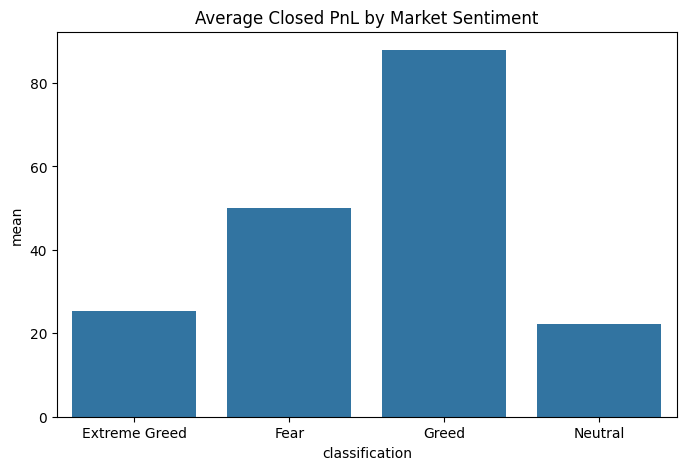

In [8]:
plt.figure(figsize=(8,5))
sns.barplot(
    data=result.reset_index(),
    x="classification",
    y="mean"
)
plt.title("Average Closed PnL by Market Sentiment")
plt.show()

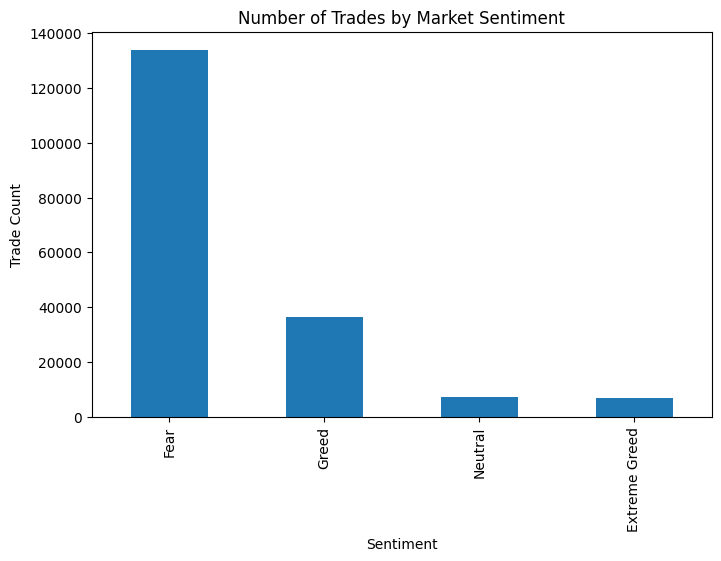

In [9]:
trade_counts = df['classification'].value_counts()

plt.figure(figsize=(8,5))
trade_counts.plot(kind='bar')
plt.title('Number of Trades by Market Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Trade Count')
plt.show()

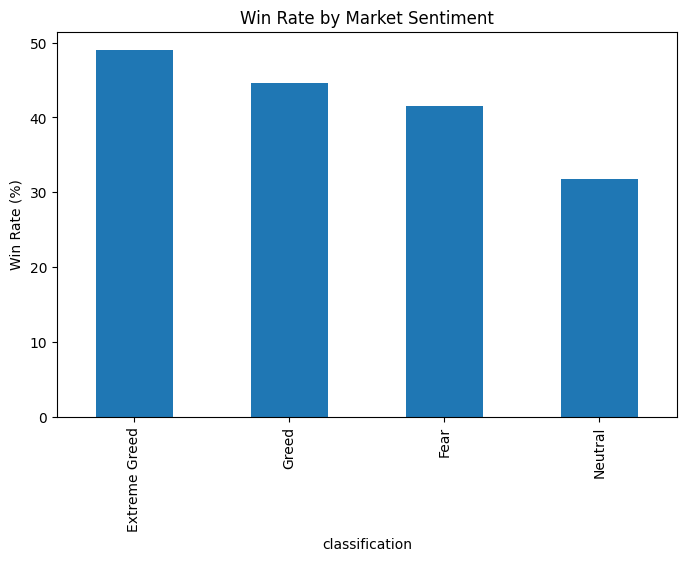

In [10]:
df['win'] = df['Closed PnL'] > 0

win_rate = (
    df.groupby('classification')['win']
      .mean()
      .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))
win_rate.plot(kind='bar')
plt.title('Win Rate by Market Sentiment')
plt.ylabel('Win Rate (%)')
plt.show()

Key Findings
1. Market Sentiment Significantly Influences Profitability
The highest average Closed PnL was observed during Greed periods (~88 per trade), indicating that traders generally performed best when market sentiment was positive.

2. Fear Drives the Highest Trading Activity
More than 130,000 trades occurred during Fear periods, far exceeding all other sentiment categories. This suggests that traders become more active when markets are uncertain or volatile.

3. Extreme Greed Shows a Higher Win Rate but Lower Profitability
Although Extreme Greed achieved the highest win rate (~49%), its average profit per trade was much lower than Greed. This indicates that traders may win more frequently but earn smaller profits or take suboptimal risk-reward trades.

4. Neutral Markets Offer the Weakest Performance
Neutral sentiment produced both the lowest average profitability and the lowest win rate (~32%), suggesting fewer trading opportunities and less market direction.

5. Positive Sentiment Improves Success Rate
Win rates increased from Fear (~41%) to Greed (~45%) and peaked in Extreme Greed (~49%), showing a positive relationship between market optimism and trade success.

Recommendations

Recommendation 1: Incorporate Market Sentiment into Trading Decisions
Bitcoin Fear & Greed sentiment should be used as an additional signal when evaluating trading opportunities, as trader performance varies across sentiment regimes.

Recommendation 2: Focus on High-Quality Trades During Greed
Since average profitability is highest during Greed periods, traders may benefit from allocating more capital to strong setups when sentiment is positive.

Recommendation 3: Remain Active During Fear Markets
Fear periods generated the largest volume of profitable trading activity. Rather than avoiding fearful markets, traders should identify opportunities created by increased volatility.

Recommendation 4: Exercise Caution During Extreme Greed
Despite a high win rate, profitability declines during Extreme Greed. Traders should avoid excessive leverage and overconfidence during highly optimistic market conditions.

Recommendation 5: Reduce Exposure During Neutral Markets
The lowest win rate and average profitability occurred during Neutral sentiment, indicating that traders may benefit from being more selective when market direction is unclear.

Conclusion

This study analyzed over 211,000 Hyperliquid trades alongside the Bitcoin Fear & Greed Index to investigate the relationship between market sentiment and trader performance.

The results demonstrate a clear connection between sentiment and trading outcomes. Greed periods generated the highest average profits, while Fear periods accounted for the majority of trading activity and substantial overall profitability. Although Extreme Greed produced the highest win rate, profitability declined significantly, suggesting diminishing returns from excessive market optimism. Neutral markets exhibited the weakest performance across key metrics.

Overall, the findings indicate that market sentiment is a valuable contextual indicator for understanding trader behavior and improving decision-making. Incorporating sentiment analysis into trading strategies may help traders optimize risk management, identify favorable market conditions, and avoid periods where performance tends to deteriorate.